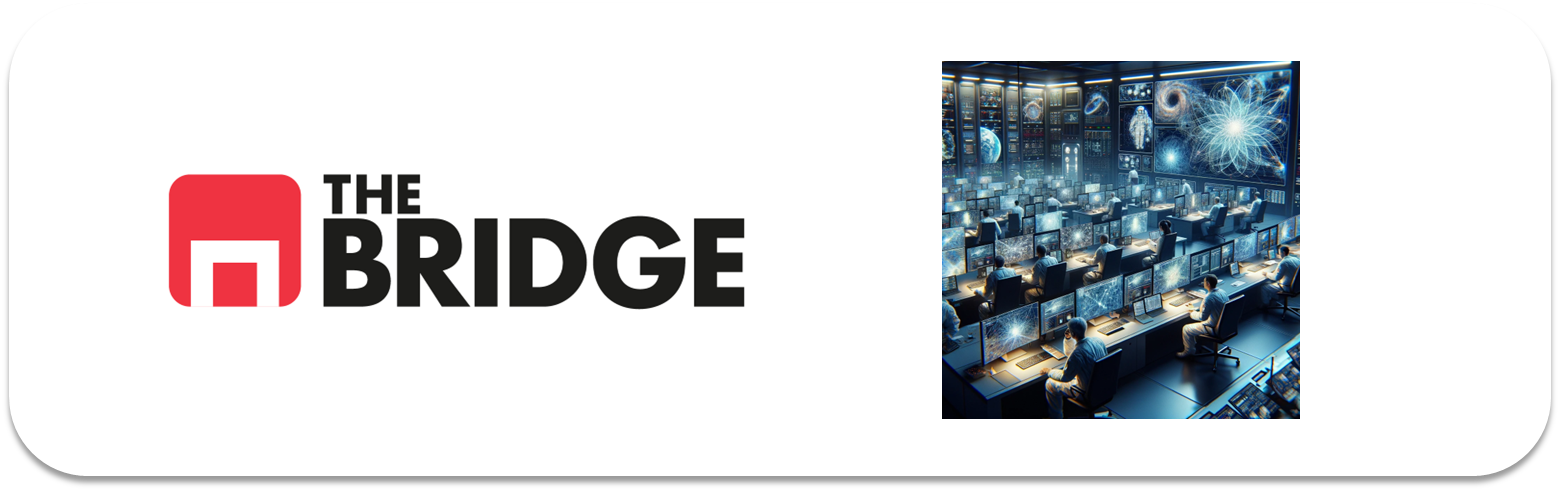

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [8]:
ruta_train = "data/seg_train"
ruta_test = "data/seg_test"

tamano_imagen = (96, 96)
tamano_lote = 32
semilla = 42

datos_entrenamiento = tf.keras.utils.image_dataset_from_directory(
    ruta_train,
    validation_split=0.2,
    subset="training",
    seed=semilla,
    image_size=tamano_imagen,
    batch_size=tamano_lote
)

datos_validacion = tf.keras.utils.image_dataset_from_directory(
    ruta_train,
    validation_split=0.2,
    subset="validation",
    seed=semilla,
    image_size=tamano_imagen,
    batch_size=tamano_lote
)

datos_test = tf.keras.utils.image_dataset_from_directory(
    ruta_test,
    image_size=tamano_imagen,
    batch_size=tamano_lote,
    shuffle=False
)

nombres_clases = datos_entrenamiento.class_names

print("Clases:", nombres_clases)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


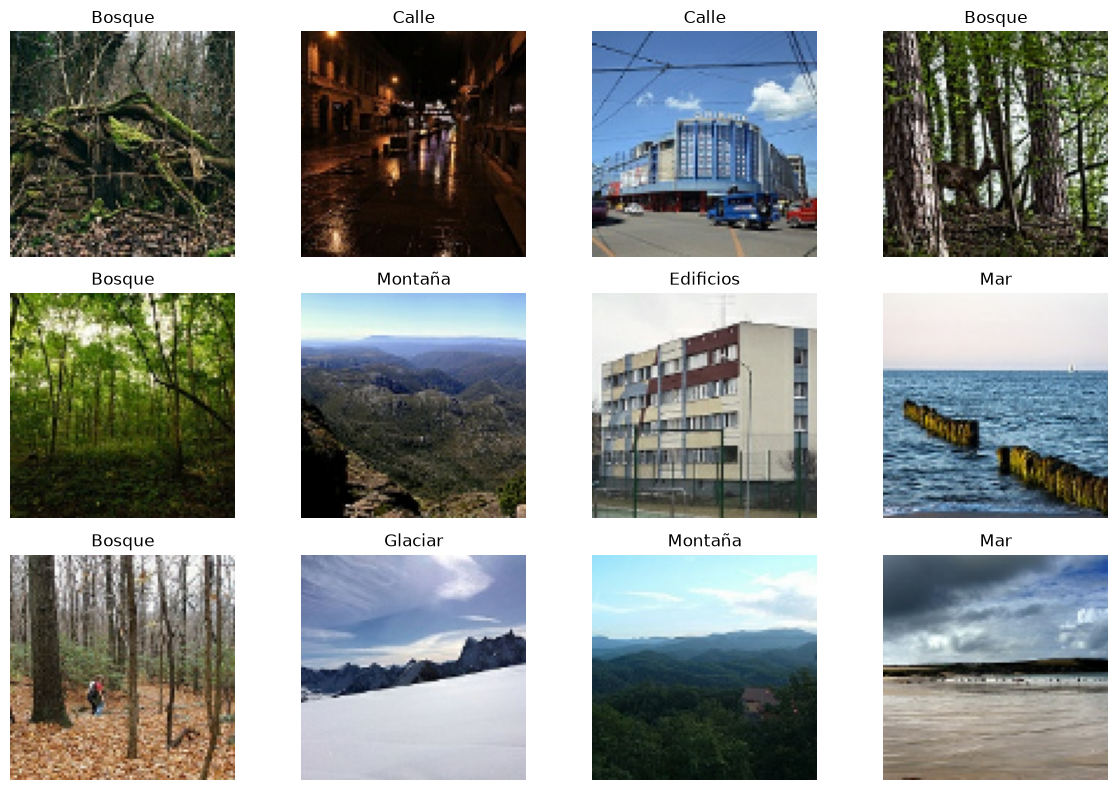

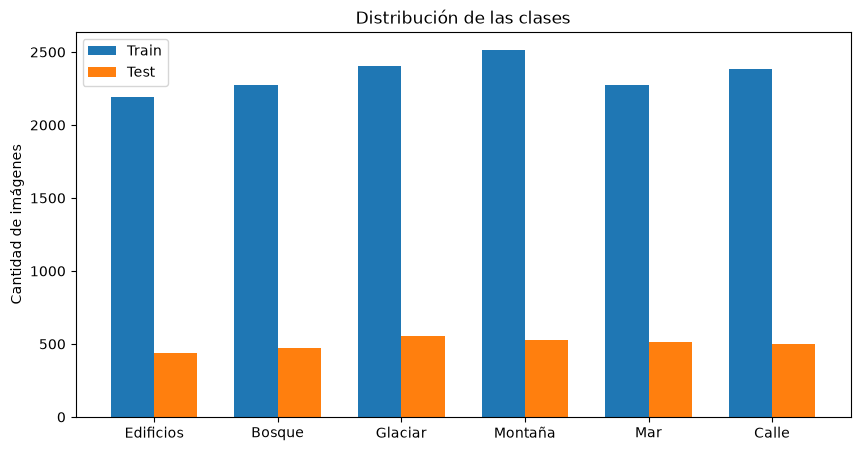

In [9]:
nombres_clases_es = [
    "Edificios",
    "Bosque",
    "Glaciar",
    "Montaña",
    "Mar",
    "Calle"
]

def mostrar_imagenes(datos):
    plt.figure(figsize=(12, 8))

    for imagenes, etiquetas in datos.take(1):
        for indice in range(12):
            eje = plt.subplot(3, 4, indice + 1)
            plt.imshow(imagenes[indice].numpy().astype("uint8"))
            plt.title(nombres_clases_es[etiquetas[indice]])
            plt.axis("off")

    plt.tight_layout()
    plt.show()


mostrar_imagenes(datos_entrenamiento)

cantidad_train = [
    len(os.listdir(os.path.join(ruta_train, clase)))
    for clase in nombres_clases
]

cantidad_test = [
    len(os.listdir(os.path.join(ruta_test, clase)))
    for clase in nombres_clases
]

posiciones = np.arange(len(nombres_clases_es))
ancho = 0.35

plt.figure(figsize=(10, 5))
plt.bar(
    posiciones - ancho / 2,
    cantidad_train,
    ancho,
    label="Train"
)
plt.bar(
    posiciones + ancho / 2,
    cantidad_test,
    ancho,
    label="Test"
)

plt.xticks(posiciones, nombres_clases_es)
plt.title("Distribución de las clases")
plt.ylabel("Cantidad de imágenes")
plt.legend()
plt.show()

In [10]:
def preparar_datos(imagenes, etiquetas):
    imagenes = preprocess_input(imagenes)
    return imagenes, etiquetas


datos_entrenamiento = datos_entrenamiento.map(
    preparar_datos,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

datos_validacion = datos_validacion.map(
    preparar_datos,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

datos_test = datos_test.map(
    preparar_datos,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

for imagenes, etiquetas in datos_entrenamiento.take(1):
    print("Tamaño del lote:", imagenes.shape)
    print("Valor mínimo:", tf.reduce_min(imagenes).numpy())
    print("Valor máximo:", tf.reduce_max(imagenes).numpy())

Tamaño del lote: (32, 96, 96, 3)
Valor mínimo: -1.0
Valor máximo: 1.0


In [11]:
modelo_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

modelo_base.trainable = False

print("Modelo seleccionado:", modelo_base.name)
print("Cantidad de capas:", len(modelo_base.layers))
print("Capas entrenables:", len(modelo_base.trainable_weights))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Modelo seleccionado: mobilenetv2_1.00_96
Cantidad de capas: 154
Capas entrenables: 0


In [12]:
numero_clases = len(nombres_clases)

entradas = Input(shape=(96, 96, 3))

x = modelo_base(entradas, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

salidas = Dense(
    numero_clases,
    activation="softmax"
)(x)

modelo_transfer = Model(
    inputs=entradas,
    outputs=salidas
)

modelo_transfer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_transfer.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
parada_transfer = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

historial_transfer = modelo_transfer.fit(
    datos_entrenamiento,
    validation_data=datos_validacion,
    epochs=10,
    callbacks=[parada_transfer]
)

Epoch 1/10


/opt/homebrew/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.8749 - loss: 0.3523 - val_accuracy: 0.9173 - val_loss: 0.2419
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.9198 - loss: 0.2174 - val_accuracy: 0.9177 - val_loss: 0.2329
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.9318 - loss: 0.1841 - val_accuracy: 0.9209 - val_loss: 0.2311
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.9426 - loss: 0.1532 - val_accuracy: 0.9177 - val_loss: 0.2414
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.9517 - loss: 0.1288 - val_accuracy: 0.9223 - val_loss: 0.2418
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.9564 - loss: 0.1088 - val_accuracy: 0.9148 - val_loss: 0.2643


Pérdida en test: 0.2389839142560959
Precisión en test: 0.9103333353996277
              precision    recall  f1-score   support

   Edificios       0.95      0.86      0.90       437
      Bosque       0.99      0.99      0.99       474
     Glaciar       0.87      0.83      0.85       553
     Montaña       0.86      0.86      0.86       525
         Mar       0.94      0.96      0.95       510
       Calle       0.87      0.97      0.92       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



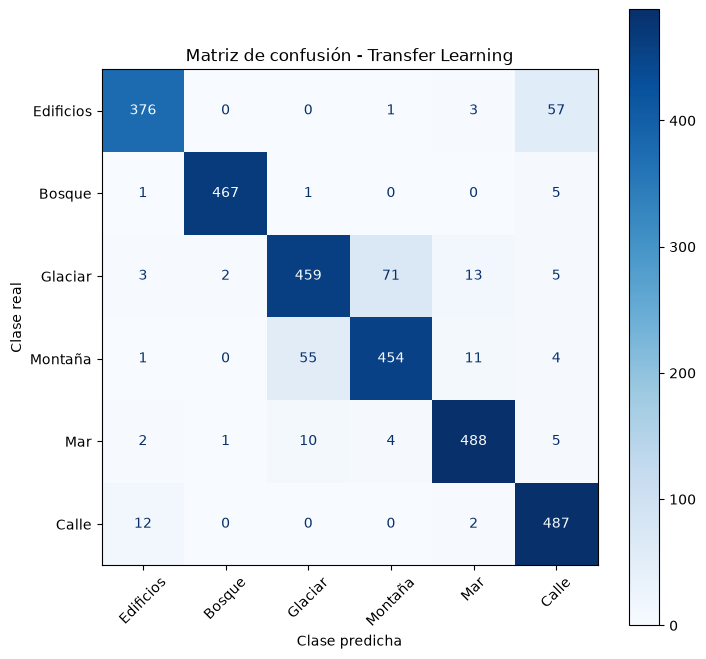

In [14]:
perdida_transfer, precision_transfer = modelo_transfer.evaluate(
    datos_test,
    verbose=0
)

probabilidades_transfer = modelo_transfer.predict(
    datos_test,
    verbose=0
)

predicciones_transfer = np.argmax(
    probabilidades_transfer,
    axis=1
)

etiquetas_test = np.concatenate([
    etiquetas.numpy()
    for _, etiquetas in datos_test
])

print("Pérdida en test:", perdida_transfer)
print("Precisión en test:", precision_transfer)

print(
    classification_report(
        etiquetas_test,
        predicciones_transfer,
        target_names=nombres_clases_es
    )
)

matriz_transfer = confusion_matrix(
    etiquetas_test,
    predicciones_transfer
)

visualizador_transfer = ConfusionMatrixDisplay(
    confusion_matrix=matriz_transfer,
    display_labels=nombres_clases_es
)

fig, eje = plt.subplots(figsize=(8, 8))

visualizador_transfer.plot(
    ax=eje,
    cmap="Blues",
    xticks_rotation=45
)

eje.set_title("Matriz de confusión - Transfer Learning")
eje.set_xlabel("Clase predicha")
eje.set_ylabel("Clase real")

plt.show()

In [15]:
modelo_base.trainable = True

for capa in modelo_base.layers:
    capa.trainable = False

for capa in modelo_base.layers[-20:]:
    if not isinstance(
        capa,
        tf.keras.layers.BatchNormalization
    ):
        capa.trainable = True

modelo_fine_tuning = modelo_transfer

modelo_fine_tuning.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(
    "Capas entrenables del modelo base:",
    sum(capa.trainable for capa in modelo_base.layers)
)

print(
    "Parámetros entrenables totales:",
    sum(
        np.prod(variable.shape)
        for variable in modelo_fine_tuning.trainable_weights
    )
)

Capas entrenables del modelo base: 13
Parámetros entrenables totales: 1359622


In [16]:
parada_fine_tuning = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

historial_fine_tuning = modelo_fine_tuning.fit(
    datos_entrenamiento,
    validation_data=datos_validacion,
    epochs=8,
    callbacks=[parada_fine_tuning]
)

Epoch 1/8


/opt/homebrew/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.9465 - loss: 0.1415 - val_accuracy: 0.9237 - val_loss: 0.2197
Epoch 2/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9589 - loss: 0.1139 - val_accuracy: 0.9262 - val_loss: 0.2168
Epoch 3/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.9631 - loss: 0.0972 - val_accuracy: 0.9227 - val_loss: 0.2254
Epoch 4/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9701 - loss: 0.0846 - val_accuracy: 0.9237 - val_loss: 0.2285
Epoch 5/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 240ms/step - accuracy: 0.9741 - loss: 0.0731 - val_accuracy: 0.9280 - val_loss: 0.2262


Pérdida en test: 0.22528214752674103
Precisión en test: 0.9193333387374878
              precision    recall  f1-score   support

   Edificios       0.93      0.89      0.91       437
      Bosque       0.99      0.99      0.99       474
     Glaciar       0.86      0.87      0.86       553
     Montaña       0.87      0.87      0.87       525
         Mar       0.96      0.95      0.96       510
       Calle       0.91      0.95      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



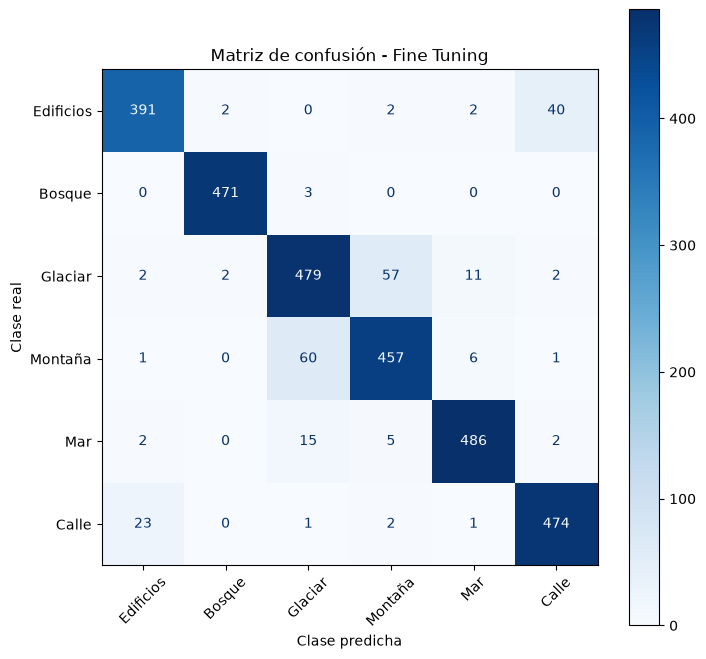

In [18]:
perdida_fine_tuning, precision_fine_tuning = modelo_fine_tuning.evaluate(
    datos_test,
    verbose=0
)

probabilidades_fine_tuning = modelo_fine_tuning.predict(
    datos_test,
    verbose=0
)

predicciones_fine_tuning = np.argmax(
    probabilidades_fine_tuning,
    axis=1
)

print("Pérdida en test:", perdida_fine_tuning)
print("Precisión en test:", precision_fine_tuning)

print(
    classification_report(
        etiquetas_test,
        predicciones_fine_tuning,
        target_names=nombres_clases_es
    )
)

matriz_fine_tuning = confusion_matrix(
    etiquetas_test,
    predicciones_fine_tuning
)

visualizador_fine_tuning = ConfusionMatrixDisplay(
    confusion_matrix=matriz_fine_tuning,
    display_labels=nombres_clases_es
)

fig, eje = plt.subplots(figsize=(8, 8))

visualizador_fine_tuning.plot(
    ax=eje,
    cmap="Blues",
    xticks_rotation=45
)

eje.set_title("Matriz de confusión - Fine Tuning")
eje.set_xlabel("Clase predicha")
eje.set_ylabel("Clase real")

plt.show()

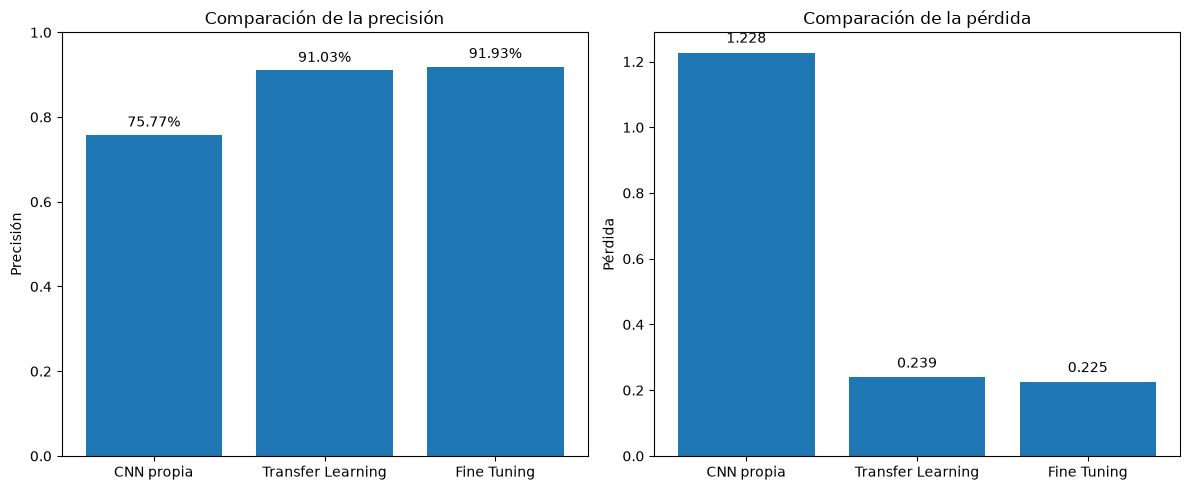

In [20]:
modelos = [
    "CNN propia",
    "Transfer Learning",
    "Fine Tuning"
]

precisiones = [
    0.7576666474342346,
    precision_transfer,
    precision_fine_tuning
]

perdidas = [
    1.2275804281234741,
    perdida_transfer,
    perdida_fine_tuning
]

fig, ejes = plt.subplots(1, 2, figsize=(12, 5))

ejes[0].bar(modelos, precisiones)
ejes[0].set_title("Comparación de la precisión")
ejes[0].set_ylabel("Precisión")
ejes[0].set_ylim(0, 1)

for indice, valor in enumerate(precisiones):
    ejes[0].text(
        indice,
        valor + 0.02,
        f"{valor:.2%}",
        ha="center"
    )

ejes[1].bar(modelos, perdidas)
ejes[1].set_title("Comparación de la pérdida")
ejes[1].set_ylabel("Pérdida")

for indice, valor in enumerate(perdidas):
    ejes[1].text(
        indice,
        valor + 0.03,
        f"{valor:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Conclusión

En este ejercicio trabajé con 14.034 imágenes para train, separando una parte para validación, y con 3.000 imágenes para test. Elegí MobileNetV2 porque era la opción más ligera para mi ordenador.

Primero hice el Transfer Learning dejando congeladas todas las capas del modelo base y entrenando solamente la nueva cabeza. Este modelo consiguió una precisión del 91,03% en test y una pérdida de 0,239.

Después hice el Fine Tuning, liberando solamente las últimas capas del MobileNetV2 y usando un learning rate más bajo. El resultado mejoró un poco, llegando a una precisión del 91,93% y una pérdida de 0,225. La clase que mejor identificó fue Bosque y la principal confusión fue entre Glaciar y Montaña.

Comparando estos resultados con la CNN propia del ejercicio anterior, que consiguió una precisión del 75,77%, se ve una mejora bastante grande al usar un modelo preentrenado. En este caso, el Fine Tuning fue el mejor modelo, aunque la diferencia con el Transfer Learning fue pequeña.